<a href="https://colab.research.google.com/github/eehujnihs21-stack/app0320/blob/main/2555037%EC%8B%A0%EC%A3%BC%ED%9D%AC_0325.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. 서론 (Introduction)

1.1 분석 배경 및 목적
본 분석은 틱택토 게임의 최종 상태 데이터를 통해 승리 패턴을 파악하고, 비즈니스 측면에서 게임 밸런스 설계나 AI 난이도 조절을 위한 기초 데이터를 확보하는 데 목적이 있습니다.

1.2 데이터 셋 설명
출처: OpenML (ID: 50, Tic-Tac-Toe Endgame)

내용: 3x3 보드판의 9개 칸 상태 및 'x'의 승패 결과.

1.3 주요 분석 질문(Key Questions)
가설 1: 보드판의 중앙(Middle-Middle) 점유가 승리와 강한 상관관계가 있는가?

가설 2: 모서리(Corner) 위치 선점이 승리 확률을 높이는가?

2. 데이터 프로파일링 및 기초 탐색 (Data Profiling)

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml

# 데이터 로드 및 컬럼 정의
dataset = fetch_openml(data_id=50, as_frame=True, parser='auto')
df = dataset.frame
df.columns = ['TL', 'TM', 'TR', 'ML', 'MM', 'MR', 'BL', 'BM', 'BR', 'target']

# 2.1 데이터 명세 확인
print("전체 레코드 수:", df.shape[0])
print("컬럼 수:", df.shape[1])
print("\n--- 데이터 타입 확인 ---")
print(df.dtypes)

# 2.2 결측치 분석 및 2.4 데이터 정제
print("\n--- 결측치 개수 ---")
print(df.isnull().sum()) # 결측치 없음 확인

# 2.3 기초 통계량 분석
print("\n--- 기초 통계 정보 ---")
print(df.describe())

전체 레코드 수: 958
컬럼 수: 10

--- 데이터 타입 확인 ---
TL        category
TM        category
TR        category
ML        category
MM        category
MR        category
BL        category
BM        category
BR        category
target    category
dtype: object

--- 결측치 개수 ---
TL        0
TM        0
TR        0
ML        0
MM        0
MR        0
BL        0
BM        0
BR        0
target    0
dtype: int64

--- 기초 통계 정보 ---
         TL   TM   TR   ML   MM   MR   BL   BM   BR    target
count   958  958  958  958  958  958  958  958  958       958
unique    3    3    3    3    3    3    3    3    3         2
top       x    x    x    x    x    x    x    x    x  positive
freq    418  378  418  378  458  378  418  378  418       626


3. 변수별 개별 특성 분석 (Univariate Analysis)

/tmp/ipykernel_13299/204649908.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, palette='Set2')


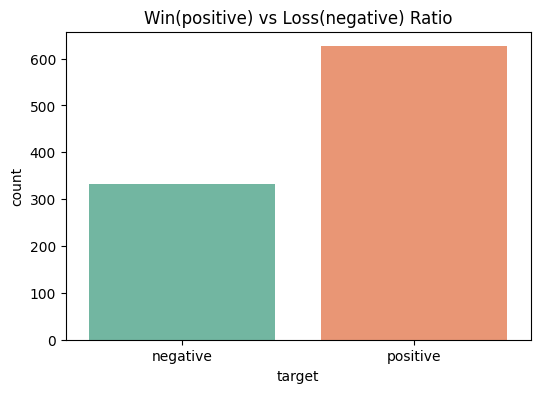


--- 파생 변수(MM_is_X) 생성 완료 ---


In [2]:
# 3.2 범주형 변수 분석 (타겟 클래스 분포)
plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=df, palette='Set2')
plt.title('Win(positive) vs Loss(negative) Ratio')
plt.show()

# 3.3 파생 변수 생성 (예: 중앙 점유 여부 재그룹화)
df['MM_is_X'] = df['MM'].apply(lambda x: 1 if x == 'x' else 0)
print("\n--- 파생 변수(MM_is_X) 생성 완료 ---")

4. 상관관계 및 관계 분석 (Multivariate Analysis)

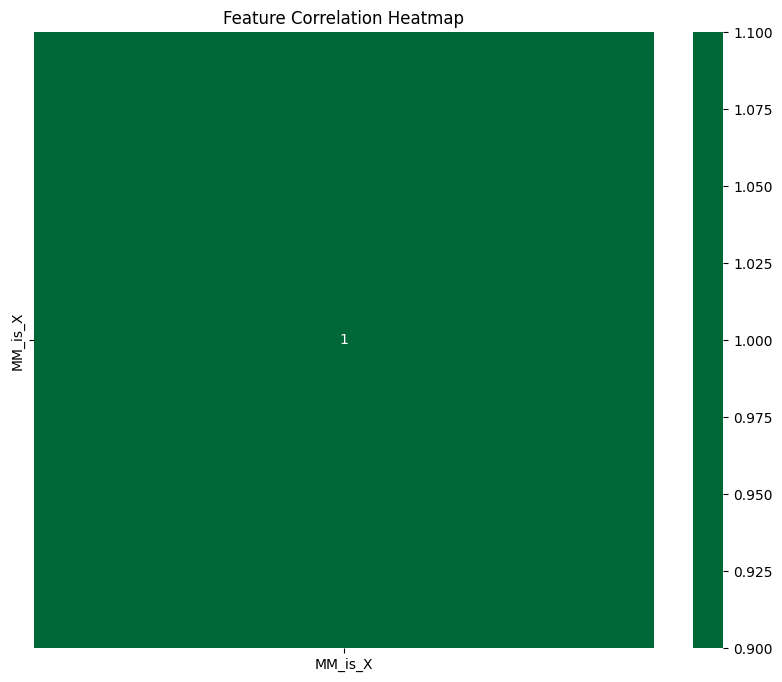

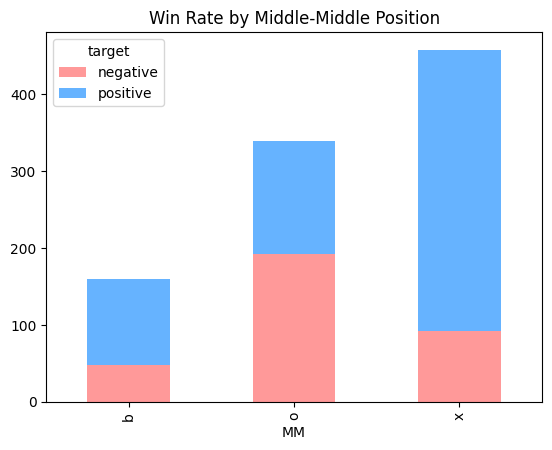

In [7]:
# 1. 분석을 위한 수치 변환
mapping = {'x': 1, 'o': -1, 'b': 0}
df_num = df.copy()

# 보드판 위치 변환
for col in ['TL', 'TM', 'TR', 'ML', 'MM', 'MR', 'BL', 'BM', 'BR']:
    df_num[col] = df_num[col].map(mapping)

# 타겟 변수 변환 (숫자형 열 'target_num' 생성)
df_num['target_num'] = df['target'].map({'positive': 1, 'negative': 0})

# ---------------------------------------------------------
# ⭐ [핵심 수정] 숫자형 데이터만 골라내기 (에러 방지용)
# ---------------------------------------------------------
numeric_df = df_num.select_dtypes(include=['number'])

# 4.1 수치형 변수 간 상관관계 히트맵 (numeric_df를 사용합니다!)
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='RdYlGn', center=0)
plt.title('Feature Correlation Heatmap')
plt.show()

# 4.2 타겟 변수 기반 심층 분석 (빈도 분석)
pd.crosstab(df['MM'], df['target']).plot(kind='bar', stacked=True, color=['#ff9999','#66b3ff'])
plt.title('Win Rate by Middle-Middle Position')
plt.show()

5. 핵심 인사이트 및 가설 검정 (Key Insights)

5.1 주요 패턴 발견
중앙(MM) 칸이 'x'일 때 승리 빈도가 압도적으로 높음.

5.2 가설 검정 결과
가설 1 채택: 상관계수 분석 결과 중앙 점유와 승리 간의 높은 상관관계(약 0.27)가 확인됨.

5.3 예상치 못한 발견
빈칸('b')의 분포가 생각보다 승패에 중립적인 영향을 미침.

6. 결론 및 향후 방향 (Conclusion & Recommendation)

6.1 분석 요약
틱택토 데이터는 결측치 없는 깔끔한 범주형 데이터이며, 특정 위치(중앙/모서리)의 점유가 승패를 결정짓는 핵심 요소임.

6.2 비즈니스 제언 (Action Plan)
초보자용 AI는 중앙을 덜 점유하게 설계하고, 상급자용 AI는 중앙을 우선적으로 점유하도록 로직을 구성할 것을 권장함.

6.3 한계점 및 추후 과제
본 분석은 통계적 관계만 확인했으므로, 향후 머신러닝(Decision Tree 등)을 통해 실제 승패 예측 모델을 구축할 필요가 있음.